## knn classifier from scratch

In [6]:
# knn regressor and classifier are used on the same logic 
# the only difference is that in the end classifier uses majority votes while regressor just takes the average of the values

In [7]:
import numpy as np
import seaborn as sns
import pandas as pd

In [12]:
## knn classifier from scratch

class knn_classifier:

    # define the constructor
    # step 1 : initialise k

    def __init__(self, k = 3):
        self.k = k

    # create function to calculate euclidean distance
    def _e_distance(self, x1, x2):
        return np.sqrt(np.sum((x2-x1) ** 2))
    
    # create function to fit()
    # knn is a lazy learner, doesnt do calculations and computations in the fit() function
    # it just stores the data in this function
    
    def fit(self, X_train, y_train): 

        self.X_train = X_train # using self as we want to remember these values and use it further
        self.y_train = y_train
        
        
    # create function to predict()
    # unlike lnr or lgr, knn does all the heavy lifting in predict() rather than in fit()
    
    def predict(self, X_test): 
        
        y_pred = []
         
        for x in X_test:
         
            # we calculate all the distances in a list
             
            distances = []
            for x_train in self.X_train:
                distance = self._e_distance(x, x_train) # distance between the new point and the x train points
                distances.append(distance)
    
            # now we need to find the k nearest neighbours
            # we will have to sort the distances list, but we dont want the distances value, but the coordinates of the points 
    
            knn_indices = np.argsort(distances)[:self.k] # this function gives us the index of the nearest neighbos rather than their 
                                                         # distances, it helps us find k nearest neighbors not k nearest distances
                                                         # [:self.k] gives us that part of the list from the 0th index to the kth index
    
            # from the knn_indices we calculate their classes and store them in a list
            
            knn_classes = []
            for i in knn_indices:
                knn_class = self.y_train[i] # for every point in knn_indices, y_train will have correspoding class 
                knn_classes.append(knn_class)
    
            # now the last step is to find the majority class from all the classes
            
            majority_class = np.argmax(np.bincount(knn_classes)) # bincount creates bins for each class and stores frequencies
            y_pred.append(majority_class)                        # argmax takes that tuple and returns the index of the max f
    
        return np.array(y_pred)       
                 

In [13]:
# create, predict and check

knn_classifier = knn_classifier()
knn_classifier.fit(X_train, y_train)
y_pred = knn_classifier.predict(X_test)

print(y_pred)

[0 1]


In [5]:
# Data
X_train = np.array([
    [1, 2], # every datapoint has 2 input feature
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]
])

y_train = np.array([0, 0, 0, 1, 1]) # every datapoint has 1 output feature

X_test = np.array([
    [2, 2],
    [6, 6]
])

<Axes: xlabel='x1', ylabel='x2'>

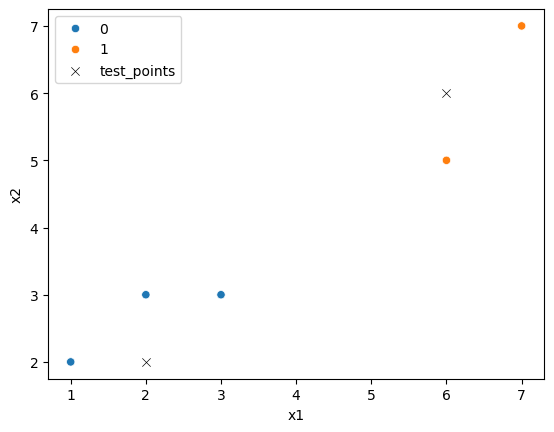

In [18]:
# visualise

X_train_df = pd.DataFrame(X_train, columns = ["x1", "x2"])
X_train_df["label"] = y_train

X_test_df = pd.DataFrame(X_test, columns = ["x1","x2"])

sns.scatterplot(
    x = X_train_df["x1"],
    y = X_train_df["x2"],
    hue = X_train_df["label"] # color wise difference
)

sns.scatterplot(
    x = X_test_df["x1"],
    y = X_test_df["x2"],
    color = "black",
    marker = "x",
    label = "test_points"
)